In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv ("../data/startup_50.csv")
df.head ()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [ ]:
df.describe ()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [ ]:
df.isnull().sum ()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [163]:
df.duplicated().sum()

np.int64(0)

In [164]:
correlations = df.drop("State", axis=1).corr()
correlations

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

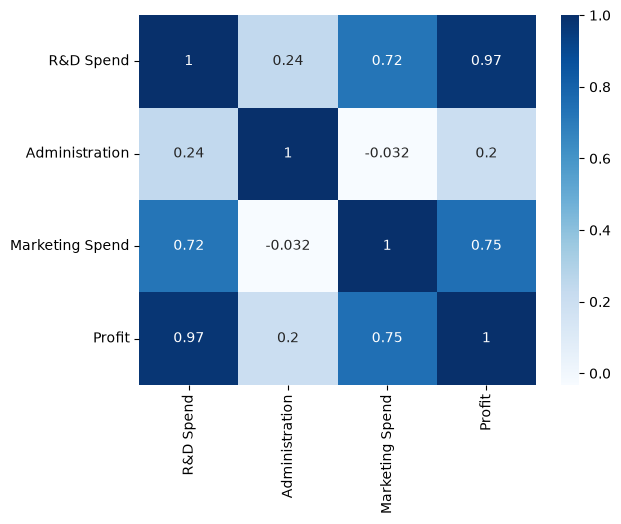

In [165]:
sns.heatmap (correlations, annot= True , cmap= "Blues")

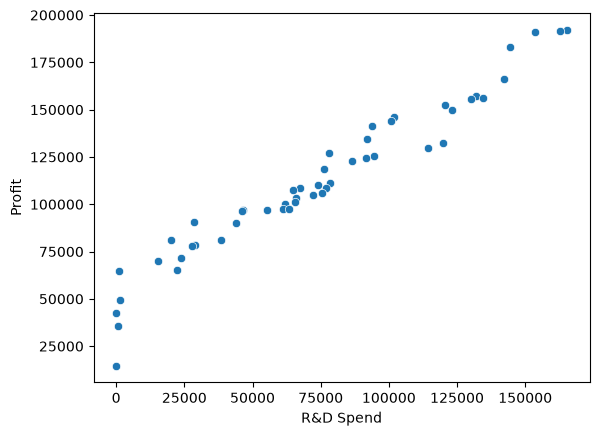

In [ ]:
sns.scatterplot (x="R&D Spend", y="Profit", data=df)
plt.show ()

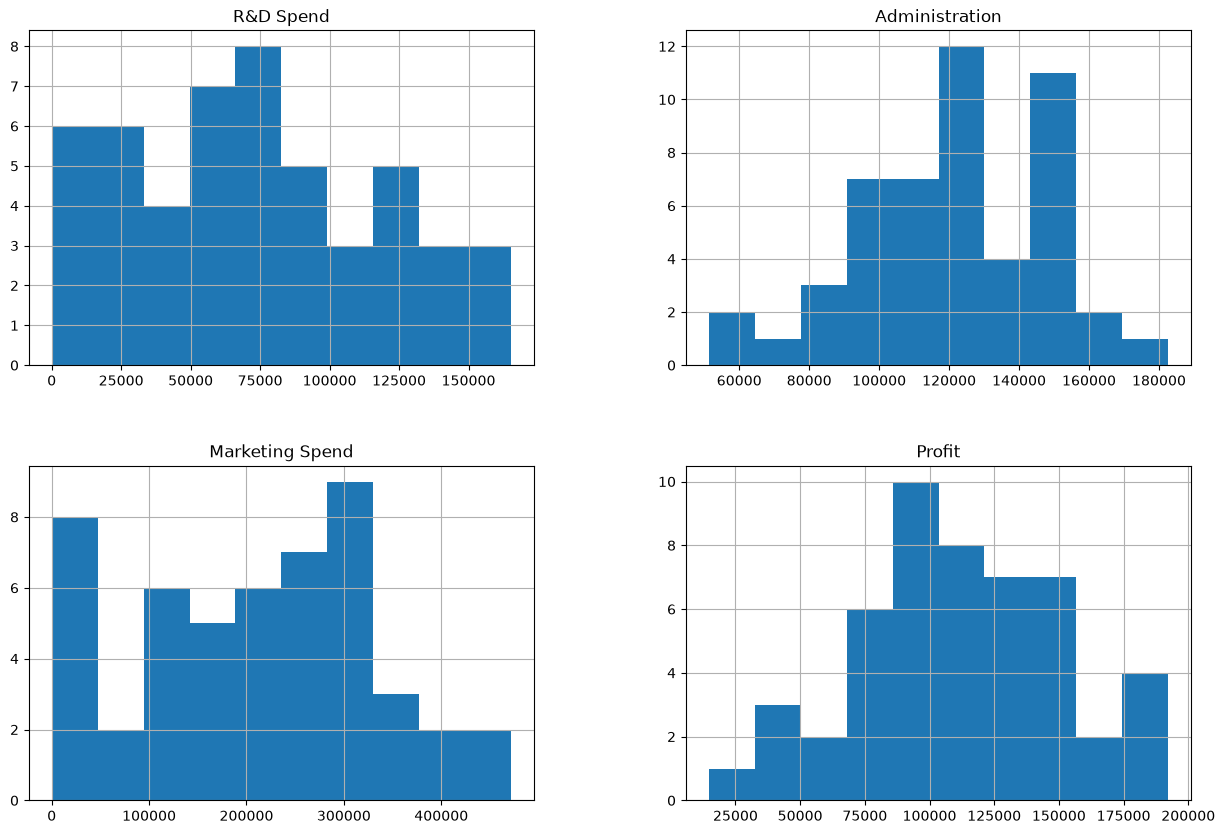

In [167]:
df.hist(figsize=(15,10))
plt.show()

In [ ]:
df ["State"].unique ()

<StringArray>
['New York', 'California', 'Florida']
Length: 3, dtype: str

In [169]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df["State"] = le.fit_transform(df["State"])

In [170]:
df.head(10)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [171]:
df = pd.read_csv ("../data/startup_50.csv")
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
state_dummy = ohe.fit_transform(df[["State"]]).toarray()
np.unique(state_dummy, axis=0)

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [172]:
df = pd.read_csv ("../data/startup_50.csv")
df_dummy = pd.get_dummies (df["State"] , drop_first=True , dtype=int)
df_dummy.head()

,Florida,New York
0,0,1
1,0,0
2,1,0
3,0,1
4,1,0


In [173]:
df= pd.concat([df, df_dummy], axis=1)
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit,Florida,New York
0,165349.20,136897.80,471784.10,New York,192261.83,0,1
1,162597.70,151377.59,443898.53,California,191792.06,0,0
2,153441.51,101145.55,407934.54,Florida,191050.39,1,0
3,144372.41,118671.85,383199.62,New York,182901.99,0,1
4,142107.34,91391.77,366168.42,Florida,166187.94,1,0


In [174]:
df.drop("State", axis=1, inplace=True)

In [175]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,Florida,New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


In [176]:
x= df.drop("Profit", axis=1)
y= df["Profit"]

In [177]:
from sklearn.preprocessing import StandardScaler

In [178]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, train_size=0.8, random_state=42
    )

In [179]:
stand = StandardScaler()
x_train = stand.fit_transform(x_train) 
# 
# for transform
# (x - mean) / std
#
x_test = stand.transform(x_test)

In [180]:
print("X_train_scaled shape:", x_train.mean())
print("X_test_scaled shape:", x_train.std())

X_train_scaled shape: -3.441691376337985e-17
X_test_scaled shape: 1.0


In [181]:
from sklearn.linear_model import LinearRegression

In [182]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[38102.27,-1864.75, 3386.18, 447.78, 3.27]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.157e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[8.47,7.78,6.43,4.27,2.83]"


In [183]:
y_pred = model.predict(x_test)

In [184]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

In [185]:
mean_absolute_error(y_test , y_pred)

6961.477813275558

In [186]:
mean_squared_error(y_test , y_pred)

82010363.04501359

In [187]:
np.sqrt(mean_squared_error(y_test , y_pred))

np.float64(9055.957323497809)

In [188]:
r2_score(y_test , y_pred)

0.8987266414319838